In [11]:
import os, numpy as np, matplotlib.pyplot as plt
import csv
from helper_functions.A_loading_helpers import load_csv_data
import helper_functions.C_preprocessing_helpers as ph

In [3]:
Xtr, Xte, ytr, id_tr, id_te = load_csv_data("data")

In [7]:
# chemins (ceux de Jakob)
classes_path = "data/feature_properties/feature_classes.json"
feature_names_path = "data/feature_properties/feature_names.csv"

fd = ph.build_feature_dictionary(classes_path, feature_names_path)
feature_names = ph.load_feature_names(feature_names_path)

[OK] Saved all pairs to: /Users/valentinepicht/Documents/ML/ml-project-1/correlation_pairs_all.csv
[OK] Saved strong pairs (|r|≥0.6) to: /Users/valentinepicht/Documents/ML/ml-project-1/correlation_pairs_strong.csv


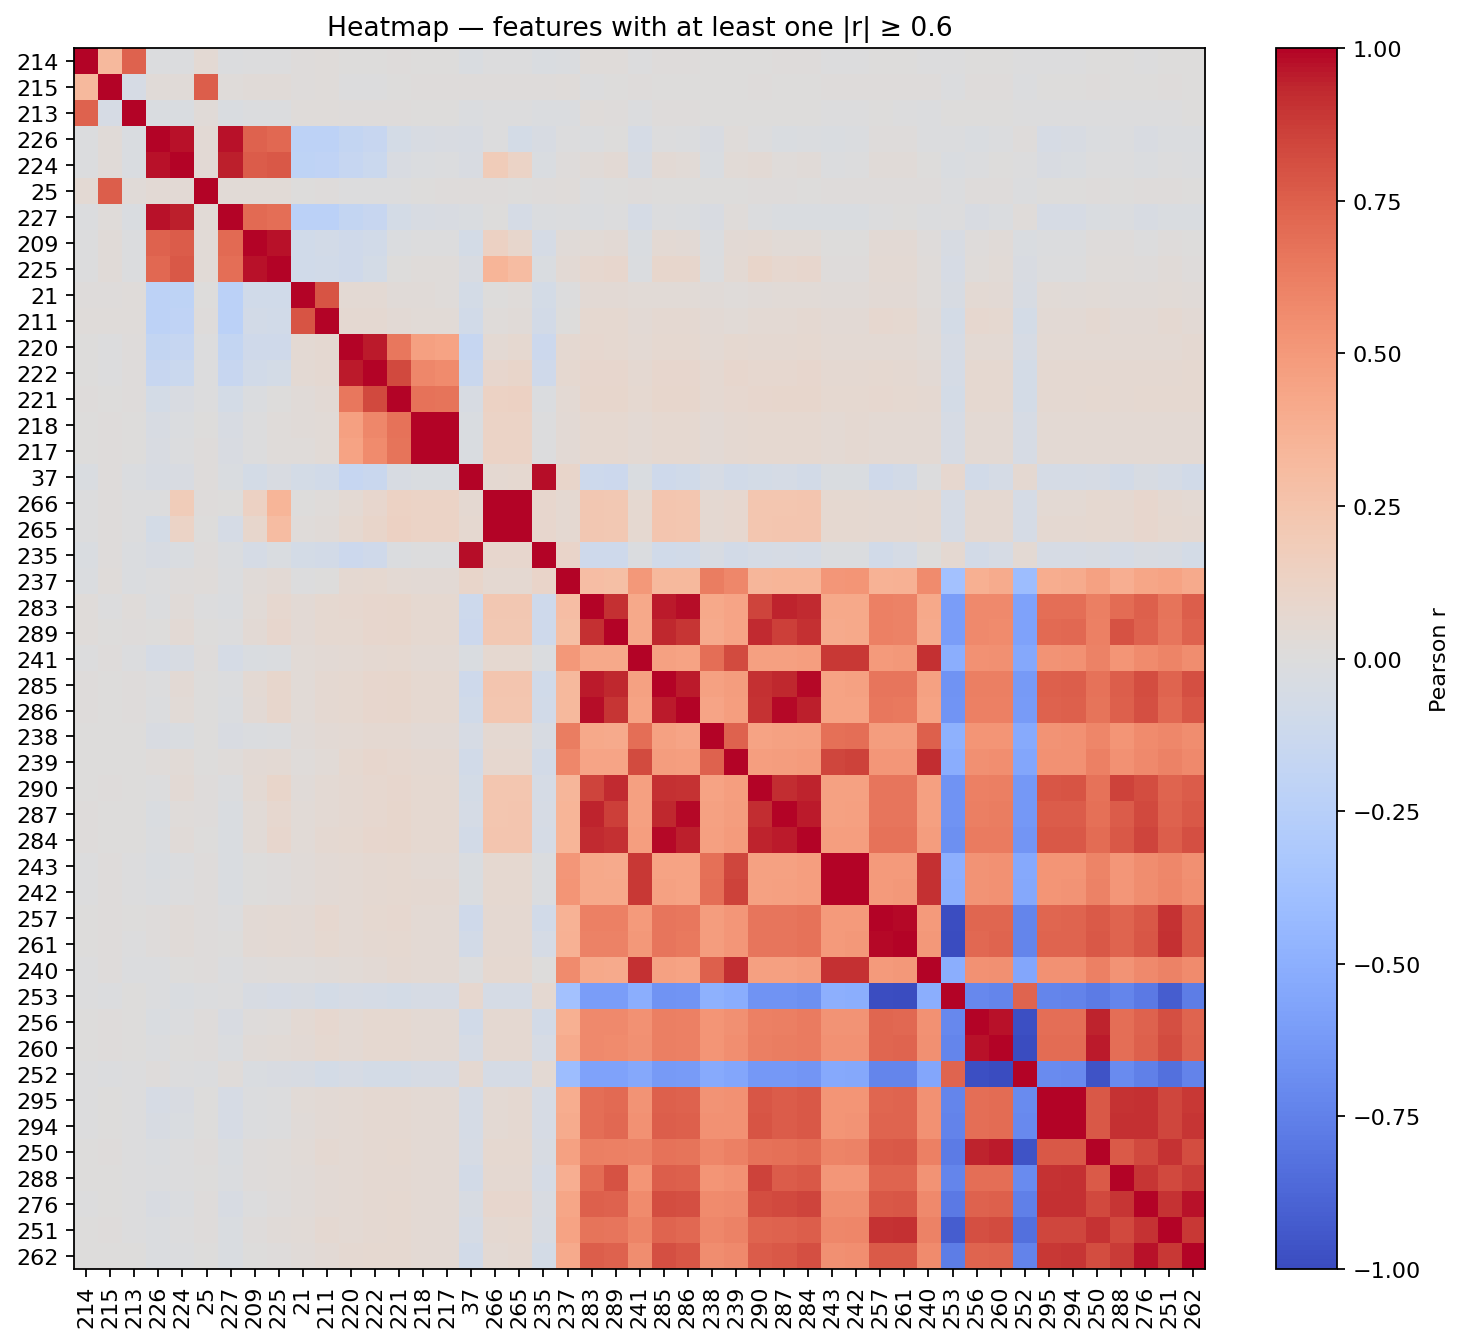

In [12]:
# ---------- 0) Inputs you (likely) already have ----------
# corr : np.ndarray square correlation matrix on filtered columns
# keep_cols : list of kept original column indices
# feature_names_filt : optional list of names aligned with corr columns
feature_names_filt = feature_names_filt if 'feature_names_filt' in globals() else None

# Clean NaNs (constant columns) and fix diagonal
if np.isnan(corr).any():
    corr = np.nan_to_num(corr, nan=0.0)
    np.fill_diagonal(corr, 1.0)

# ---------- 1) Collect ALL pairs into CSV ----------
def save_all_pairs_csv(C, names=None, path="correlation_pairs_all.csv"):
    """Save all (i<j) pairs with Pearson r into a CSV."""
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["i", "j", "feature_i", "feature_j", "pearson_r"])
        n = C.shape[0]
        for i in range(n):
            for j in range(i+1, n):
                ni = names[i] if names is not None else i
                nj = names[j] if names is not None else j
                w.writerow([i, j, ni, nj, float(C[i, j])])
    print(f"[OK] Saved all pairs to: {os.path.abspath(path)}")

# ---------- 2) Extract strong pairs and save CSV ----------
def extract_strong_pairs(C, names=None, threshold=0.6, path="correlation_pairs_strong.csv"):
    """Return indices used in strong pairs and save those pairs to CSV."""
    used = set()
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["i", "j", "feature_i", "feature_j", "pearson_r", "abs_r"])
        n = C.shape[0]
        for i in range(n):
            for j in range(i+1, n):
                r = float(C[i, j])
                if abs(r) >= threshold:
                    used.add(i); used.add(j)
                    ni = names[i] if names is not None else i
                    nj = names[j] if names is not None else j
                    w.writerow([i, j, ni, nj, r, abs(r)])
    used = np.array(sorted(used), dtype=int)
    print(f"[OK] Saved strong pairs (|r|≥{threshold}) to: {os.path.abspath(path)}")
    return used

# ---------- 3) Heatmap of ONLY the features involved in strong pairs ----------
def robust_limits(A, lo=1, hi=99):
    """Symmetric vmin/vmax around 0 using percentiles on |A|."""
    a = np.abs(A[np.isfinite(A)])
    if a.size == 0:
        return -1.0, 1.0
    vmax = np.percentile(a, hi)
    return -vmax, vmax

def spectral_order(C):
    """Visualization-only reordering to make blocks stand out (NumPy only)."""
    A = np.abs(C.copy())
    np.fill_diagonal(A, 0.0)
    d = A.sum(axis=1)
    d[d == 0] = 1.0
    Dinv = 1.0 / np.sqrt(d)
    W = (Dinv[:, None] * A) * Dinv[None, :]
    L = np.eye(len(A)) - W
    vals, vecs = np.linalg.eigh(L)
    idx = 1 if len(vals) > 1 else 0
    return np.argsort(vecs[:, idx])

def plot_strong_heatmap(C, idxs, names=None, title="Strong correlations heatmap"):
    """Plot heatmap on C[np.ix_(idxs, idxs)] with robust contrast and optional reordering."""
    if idxs.size < 2:
        print("Not enough features to plot a heatmap (need at least 2).")
        return
    S = C[np.ix_(idxs, idxs)]
    # Visualization-only ordering
    try:
        order_local = spectral_order(S)
        S = S[order_local][:, order_local]
        idxs = idxs[order_local]
    except Exception:
        pass
    vmin, vmax = robust_limits(S, 1, 99)
    plt.figure(figsize=(9.5, 8.5), dpi=160)
    im = plt.imshow(S, vmin=vmin, vmax=vmax, cmap='coolwarm', interpolation='nearest', aspect='auto')
    plt.colorbar(im, label="Pearson r")
    plt.title(title)
    n = S.shape[0]
    step = max(1, n // 25)
    ticks = np.arange(0, n, step)
    if names is not None:
        labels = [names[k] for k in idxs[ticks]]
    else:
        labels = idxs[ticks]
    plt.xticks(ticks, labels, rotation=90)
    plt.yticks(ticks, labels)
    plt.tight_layout()
    plt.show()

# ---------- 4) Run it ----------
threshold = 0.6  # adjust as you like (e.g., 0.5, 0.7, 0.8)

# 4.a) Save CSV of ALL pairs
save_all_pairs_csv(corr, names=feature_names_filt, path="correlation_pairs_all.csv")

# 4.b) Save CSV of strong pairs and get involved feature indices
strong_idxs = extract_strong_pairs(corr, names=feature_names_filt,
                                   threshold=threshold,
                                   path="correlation_pairs_strong.csv")

# 4.c) Plot heatmap restricted to features that appear in strong pairs
plot_strong_heatmap(corr, strong_idxs, names=feature_names_filt,
                    title=f"Heatmap — features with at least one |r| ≥ {threshold}")
